# Heart Failure Prediction Dataset

## - **Task 1**: Identify data quality issues in the dataset.

### Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

sns.set(style='whitegrid')

### Load Dataset

In [17]:
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
csvPath = os.path.join(path, "heart.csv")
df = pd.read_csv(csvPath)
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


### Data Quality Assessment

In [18]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

## - **Task 2**: Apply one missing value strategy and explain why.

### Detect Missing Values

In [19]:
df.isna()
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### Introduce Artificial Missing Values

In [20]:
df2 = df.copy()
df2.loc[0:5, 'Cholesterol'] = np.nan
df2.isna()
df2.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       6
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### Apply Missing Value Strategy

*I will remove the missing records because the number of missing rows is small and will not reduce model performance.*

In [21]:
df_remove = df2.dropna()
print('df with NaN: ',df2.shape)
print('df without NaN: ',df_remove.shape)
df_remove.isna().sum()

df with NaN:  (918, 12)
df without NaN:  (912, 12)


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## - **Task 3**: Detect and handle outliers using IQR.

### Detect Outliers Using IQR Method

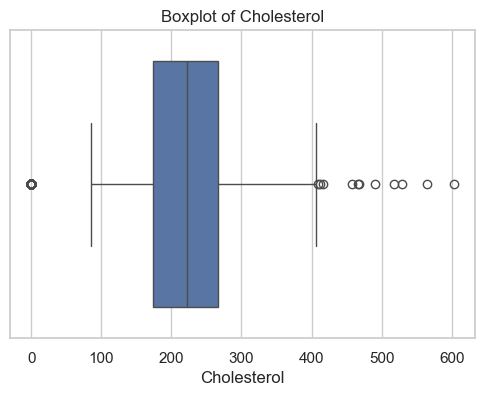

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Cholesterol'])

plt.title('Boxplot of Cholesterol')
plt.show()

In [23]:
Q1 = df['Cholesterol'].quantile(0.25)
Q3 = df['Cholesterol'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Cholesterol'] < lower) | (df['Cholesterol'] > upper)]
outliers.head(20)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
28,53,F,ATA,113,468,0,Normal,127,N,0.0,Up,0
30,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat,1
69,44,M,ASY,150,412,0,Normal,170,N,0.0,Up,0
76,32,M,ASY,118,529,0,Normal,130,N,0.0,Flat,1
103,40,M,ASY,120,466,1,Normal,152,Y,1.0,Flat,1
149,54,M,ASY,130,603,1,Normal,125,Y,1.0,Flat,1
250,44,M,ASY,135,491,0,Normal,135,N,0.0,Flat,1
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1


### Remove Outliers

In [24]:
df_no_outliers = df[(df['Cholesterol'] >= lower) & (df['Cholesterol'] <= upper)]

print('df with outliers: ',df.shape)
print('df without outliers: ',df_no_outliers.shape)

df with outliers:  (918, 12)
df without outliers:  (735, 12)


*The dataset size was extremely reduced which could mean the loss of valuable information and result in the bias of the analysis. Therefore, we replace the outliers with percentile limits.*

### Capping Outliers (Percentile Method)

In [25]:
lower_cap = df['Cholesterol'].quantile(0.05) # 5%
upper_cap = df['Cholesterol'].quantile(0.95) # 95%

df_capped = df.copy()
df_capped['Cholesterol'] = df_capped['Cholesterol'].clip(lower_cap, upper_cap)

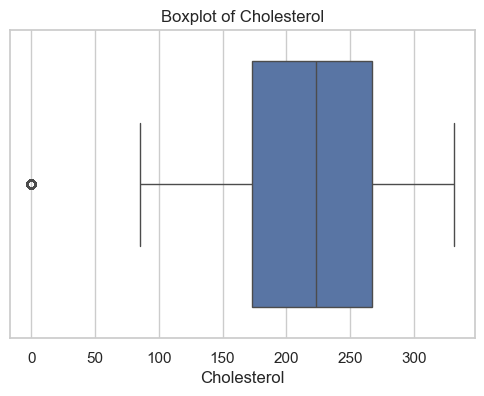

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['Cholesterol'])

plt.title('Boxplot of Cholesterol')
plt.show()

## - **Task 4**: Normalize numerical features using both Min-Max and Z-score.

### MIN-MAX

In [27]:
df[['RestingBP','Cholesterol']].head()

,RestingBP,Cholesterol
0,140,289
1,160,180
2,130,283
3,138,214
4,150,195


In [28]:
scaler = MinMaxScaler()
df_scaled = df[['RestingBP','Cholesterol']].copy()

df_scaled[['RestingBP','Cholesterol']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,RestingBP,Cholesterol
0,0.70,0.479270
1,0.80,0.298507
2,0.65,0.469320
3,0.69,0.354892
4,0.75,0.323383


### Z-Score Normalization

In [29]:
scaler = StandardScaler()
df_standardized = df[['RestingBP','Cholesterol']].copy()

df_standardized[['RestingBP','Cholesterol']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,RestingBP,Cholesterol
0,0.410909,0.825070
1,1.491752,-0.171961
2,-0.129513,0.770188
3,0.302825,0.139040
4,0.951331,-0.034755


## - **Task 5**: Apply PCA only if the numerical features show a correlation.

### Check For Correlation

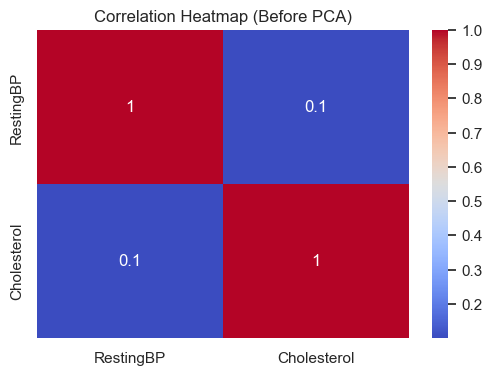

In [30]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['RestingBP','Cholesterol']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

*The correlation between `RestingBP` and `Cholesterol` is approximately *0.1*. A correlation value close to 0 indicates that there is almost **NO linear** relationship between the two*